In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/ecommerceDataset.csv", header=None)
df.columns = ['category', 'product_description']

In [ ]:
df.head()

,category,product_description
0,Household,Paper Plane Design Framed Wall Hanging Motivat...
1,Household,"SAF 'Floral' Framed Painting (Wood, 30 inch x ..."
2,Household,SAF 'UV Textured Modern Art Print Framed' Pain...
3,Household,"SAF Flower Print Framed Painting (Synthetic, 1..."
4,Household,Incredible Gifts India Wooden Happy Birthday U...


In [ ]:
df["text"] = df["product_description"]

print(df.head())

    category                                product_description  \
0  Household  Paper Plane Design Framed Wall Hanging Motivat...   
1  Household  SAF 'Floral' Framed Painting (Wood, 30 inch x ...   
2  Household  SAF 'UV Textured Modern Art Print Framed' Pain...   
3  Household  SAF Flower Print Framed Painting (Synthetic, 1...   
4  Household  Incredible Gifts India Wooden Happy Birthday U...   

                                                text  
0  Paper Plane Design Framed Wall Hanging Motivat...  
1  SAF 'Floral' Framed Painting (Wood, 30 inch x ...  
2  SAF 'UV Textured Modern Art Print Framed' Pain...  
3  SAF Flower Print Framed Painting (Synthetic, 1...  
4  Incredible Gifts India Wooden Happy Birthday U...  


# Task
Summarize the distinct categories and their counts in the `category` column of the `df` DataFrame.

## Display Distinct Categories

### Subtask:
Show all unique values present in the 'category' column of the DataFrame.


**Reasoning**:
To display all unique values from the 'category' column, I will use the `.unique()` method on that column of the `df` DataFrame.



In [ ]:
print(df['category'].unique())

['Household' 'Books' 'Clothing & Accessories' 'Electronics']


## Count Distinct Categories

### Subtask:
Count the occurrences of each unique value in the 'category' column to understand their distribution.


**Reasoning**:
To count the occurrences of each unique category, I will use the `.value_counts()` method on the 'category' column and then print the result.



In [ ]:
print(df['category'].value_counts())

category
Household                 19313
Books                     11820
Electronics               10621
Clothing & Accessories     8671
Name: count, dtype: int64


In [ ]:
encoder = LabelEncoder()
y = encoder.fit_transform(df["category"])

print(dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))


{'Books': np.int64(0), 'Clothing & Accessories': np.int64(1), 'Electronics': np.int64(2), 'Household': np.int64(3)}


In [ ]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2)
)

X = vectorizer.fit_transform(df["text"].fillna("")).toarray()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
model = Sequential([
    Dense(256, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(128, activation="relu"),
    Dense(len(encoder.classes_), activation="softmax")
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)


Epoch 1/5
1135/1135 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.8786 - loss: 0.3401 - val_accuracy: 0.9663 - val_loss: 0.1215
Epoch 2/5
1135/1135 ━━━━━━━━━━━━━━━━━━━━ 36s 32ms/step - accuracy: 0.9847 - loss: 0.0548 - val_accuracy: 0.9712 - val_loss: 0.1139
Epoch 3/5
1135/1135 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.9934 - loss: 0.0230 - val_accuracy: 0.9720 - val_loss: 0.1437
Epoch 4/5
1135/1135 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.9957 - loss: 0.0152 - val_accuracy: 0.9710 - val_loss: 0.1679
Epoch 5/5
1135/1135 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.9961 - loss: 0.0103 - val_accuracy: 0.9712 - val_loss: 0.1676


In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred_classes))


316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy: 0.974913237481408


In [ ]:
print(classification_report(
    y_test,
    y_pred_classes,
    target_names=encoder.classes_
))


                        precision    recall  f1-score   support

                 Books       0.97      0.97      0.97      2364
Clothing & Accessories       0.98      0.99      0.98      1734
           Electronics       0.98      0.97      0.97      2124
             Household       0.97      0.98      0.98      3863

              accuracy                           0.97     10085
             macro avg       0.98      0.97      0.98     10085
          weighted avg       0.97      0.97      0.97     10085



In [ ]:
cm = confusion_matrix(y_test, y_pred_classes)
print(cm)


[[2289   10   20   45]
 [   9 1710    2   13]
 [  20    4 2052   48]
 [  31   21   30 3781]]


"""
Paper Plane Design Framed Wall Hanging Motivational Office Decor Art Prints
with UV textured print, synthetic frame, ready to hang wall painting
"""

In [ ]:
sample_text = input("Enter a product description: ")



Enter a product description: Formal white skirt along with black shirt


In [ ]:
sample_vector = vectorizer.transform([sample_text]).toarray()

prediction = model.predict(sample_vector)
predicted_class = np.argmax(prediction)

print("Predicted Category:", encoder.inverse_transform([predicted_class])[0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted Category: Clothing & Accessories


In [ ]:
sample_df = df.sample(5, random_state=42)

X_sample = vectorizer.transform(sample_df["text"]).toarray()
y_sample_true = sample_df["category"]

y_sample_pred = np.argmax(model.predict(X_sample), axis=1)
y_sample_pred_labels = encoder.inverse_transform(y_sample_pred)

comparison = pd.DataFrame({
    "Original Text": sample_df["text"].str[:100],
    "True Category": y_sample_true.values,
    "Predicted Category": y_sample_pred_labels
})

print(comparison)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
                                           Original Text  \
35848  Kandy Men's Regular Fit Blazer Blue This produ...   
13005  HealthSense Chef-Mate KS 50 Digital Kitchen Sc...   
22719  Concept of Physics (2018-2019) Session (Set of...   
18453  Lista Stainless Steel Multi Functional Hammer ...   
20867                    Gardening in Urban India update   

                True Category      Predicted Category  
35848  Clothing & Accessories  Clothing & Accessories  
13005               Household               Household  
22719                   Books                   Books  
18453               Household               Household  
20867                   Books                   Books  


## Test with Multiple Custom Samples

Provide a comma-separated list of product descriptions to see the model's predictions for each.

In [ ]:
sample_texts_input = input("Enter product descriptions (comma-separated): ")
custom_sample_texts = [text.strip() for text in sample_texts_input.split(',') if text.strip()]

if custom_sample_texts:
    X_custom_sample = vectorizer.transform(custom_sample_texts).toarray()
    y_custom_sample_pred = np.argmax(model.predict(X_custom_sample), axis=1)
    y_custom_sample_pred_labels = encoder.inverse_transform(y_custom_sample_pred)

    custom_comparison = pd.DataFrame({
        "Product Description": custom_sample_texts,
        "Predicted Category": y_custom_sample_pred_labels
    })

    print(custom_comparison)
else:
    print("No product descriptions entered.")

Enter product descriptions (comma-separated): Men’s slim-fit cotton formal shirt with full sleeves and button-down collar. Soft breathable fabric suitable for office and casual wear. Available in multiple sizes.,wireless mouse along with cable,white ceramic bowl
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
                                 Product Description      Predicted Category
0  Men’s slim-fit cotton formal shirt with full s...  Clothing & Accessories
1                    wireless mouse along with cable             Electronics
2                                 white ceramic bowl               Household


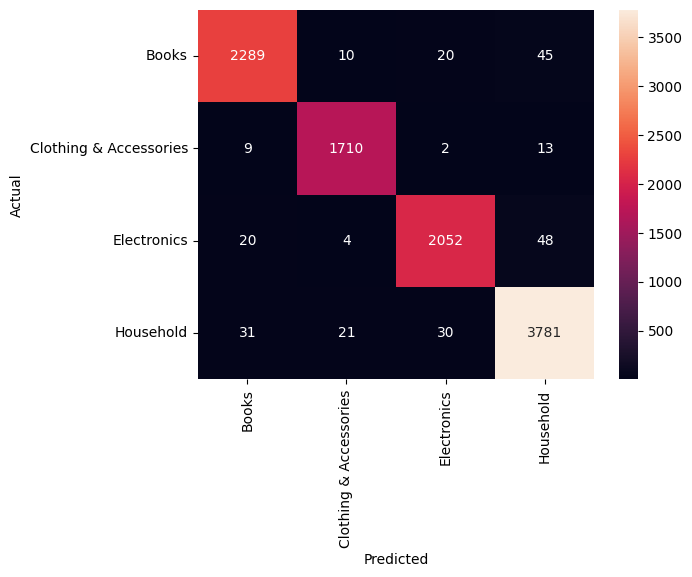

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
row = df.iloc[0]

print("Product Text:\n", row["text"])
print("Actual Category:", row["category"])

vec = vectorizer.transform([row["text"]]).toarray()
pred = np.argmax(model.predict(vec))

print("Predicted Category:", encoder.inverse_transform([pred])[0])


Product Text:
 Paper Plane Design Framed Wall Hanging Motivational Office Decor Art Prints (8.7 X 8.7 inch) - Set of 4 Painting made up in synthetic frame with uv textured print which gives multi effects and attracts towards it. This is an special series of paintings which makes your wall very beautiful and gives a royal touch. This painting is ready to hang, you would be proud to possess this unique painting that is a niche apart. We use only the most modern and efficient printing technology on our prints, with only the and inks and precision epson, roland and hp printers. This innovative hd printing technique results in durable and spectacular looking prints of the highest that last a lifetime. We print solely with top-notch 100% inks, to achieve brilliant and true colours. Due to their high level of uv resistance, our prints retain their beautiful colours for many years. Add colour and style to your living space with this digitally printed painting. Some are for pleasure and some fo